### Customer Behavior Analysis Alfido Tech Internship — Task 1 

## Project Overview
-This project analyzes customer purchasing behavior, sales trends, customer segments, and revenue patterns using exploratory data analysis (EDA) and RFM-based customer segmentation.
-Name:Aditi Kumari
-Dataset:ecommerce_customer_data_large.csv
-Date:May 2026

## Dataset Overview

The dataset contains customer transaction information including:
- Customer demographics
- Product categories
- Sales and revenue
- Payment methods
- Return information
- Purchase dates

### Objectives
- Analyze sales performance
- Identify customer spending patterns
- Examine return behavior
- Perform customer segmentation using RFM analysis

### Dataset Upload

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
df = pd.read_csv('ecommerce_customer_data_large.csv')
print(df.shape)
print(df.head())

(250000, 13)
   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        44605  2023-05-03 21:30:02             Home            177         1   
1        44605  2021-05-16 13:57:44      Electronics            174         3   
2        44605  2020-07-13 06:16:57            Books            413         1   
3        44605  2023-01-17 13:14:36      Electronics            396         3   
4        44605  2021-05-01 11:29:27            Books            259         4   

   Total Purchase Amount Payment Method  Customer Age  Returns Customer Name  \
0                   2427         PayPal            31      1.0   John Rivera   
1                   2448         PayPal            31      1.0   John Rivera   
2                   2345    Credit Card            31      1.0   John Rivera   
3                    937           Cash            31      0.0   John Rivera   
4                   2598         PayPal            31      1.0   John Rivera   

   Age  Gender  Chu

In [5]:
print(df.columns.tolist())
print(df['Returns'].value_counts())

['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']
Returns
1.0    101476
0.0    101142
Name: count, dtype: int64


## Data Cleaning

### Missing Value Analysis
Checking the dataset for missing values to ensure data quality before analysis.

In [4]:

print("Missing Values:")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)
df['Purchase Date'] = pd.to_datetime
(df['Purchase Date'])

df = df[df['Quantity'] > 0]
df = df[df['Product Price'] > 0]
df = df[df['Total Purchase Amount'] > 0]

print("\nCleaned Data Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Missing Values:
Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

Cleaned Data Shape: (250000, 13)

Data Types:
Customer ID                       int64
Purchase Date            datetime64[us]
Product Category                    str
Product Price                     int64
Quantity                          int64
Total Purchase Amount             int64
Payment Method                      str
Customer Age                      int64
Returns                         float64
Customer Name                       str
Age                               int64
Gender                              str
Churn                             int64
d

SUMMARY STATISTICS

In [6]:

print("=== MEAN ===")
print(df[['Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age']].mean())

print("\n=== MEDIAN ===")
print(df[['Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age']].median())

print("\n=== MODE ===")
print(df[['Product Category', 'Payment Method', 'Gender']].mode().iloc[0])

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== MEAN ===
Product Price             254.742724
Quantity                    3.004936
Total Purchase Amount    2725.385196
Customer Age               43.798276
dtype: float64

=== MEDIAN ===
Product Price             255.0
Quantity                    3.0
Total Purchase Amount    2725.0
Customer Age               44.0
dtype: float64

=== MODE ===
Product Category    Electronics
Payment Method      Credit Card
Gender                     Male
Name: 0, dtype: str

=== MISSING VALUES ===
Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

=== DATA TYPES ===
Customer ID                int64
Purchase Date                str
Product C

.Data Visualization
 Total Sales by Product Category

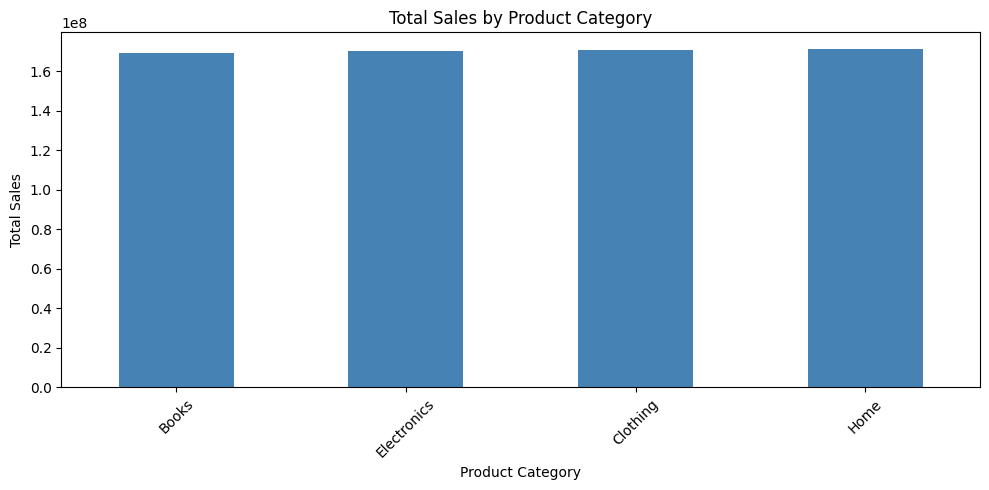

Top Category: Electronics

Category counts: Product Category
Electronics    62630
Clothing       62581
Home           62542
Books          62247
Name: count, dtype: int64


In [7]:

plt.figure(figsize=(10, 5))
df.groupby('Product Category')['Total Purchase Amount'].sum().sort_values().plot(kind='bar', color='steelblue')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_chart.png')
plt.show()
print("Top Category:", df['Product Category'].mode()[0])
print("\nCategory counts:", df['Product Category'].value_counts())


## Monthly Sales Trend

A line chart is used to analyze sales fluctuations over time and identify seasonal patterns.

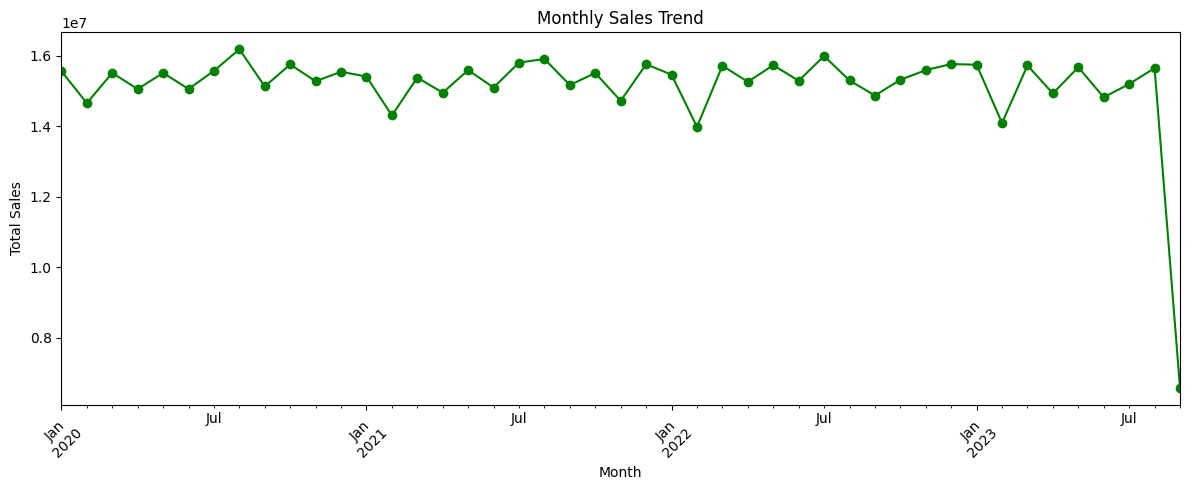

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Convert the 'Purchase Date' column to datetime objects safely
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# 2. Now you can safely use the .dt accessor
df['Month'] = df['Purchase Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

# 3. Plotting (Your original plotting code works perfectly!)
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('line_chart.png')
plt.show()

Category Revenue Breakdown

In [11]:
category_sales = df.groupby('Product Category')['Total Purchase Amount'].sum()
category_pct = (category_sales / category_sales.sum() * 100).round(1)
print("Sales by Category:")
print(category_sales)
print("\nPercentage:")
print(category_pct)
print("\nTotal Revenue:", category_sales.sum())

Sales by Category:
Product Category
Books          169345236
Clothing       170716122
Electronics    170146025
Home           171138916
Name: Total Purchase Amount, dtype: int64

Percentage:
Product Category
Books          24.9
Clothing       25.1
Electronics    25.0
Home           25.1
Name: Total Purchase Amount, dtype: float64

Total Revenue: 681346299


Yearly Revenue Trend

Yearly Revenue:
Year
2020    184877504
2021    183672481
2022    184344727
2023    128451587
Name: Total Purchase Amount, dtype: int64


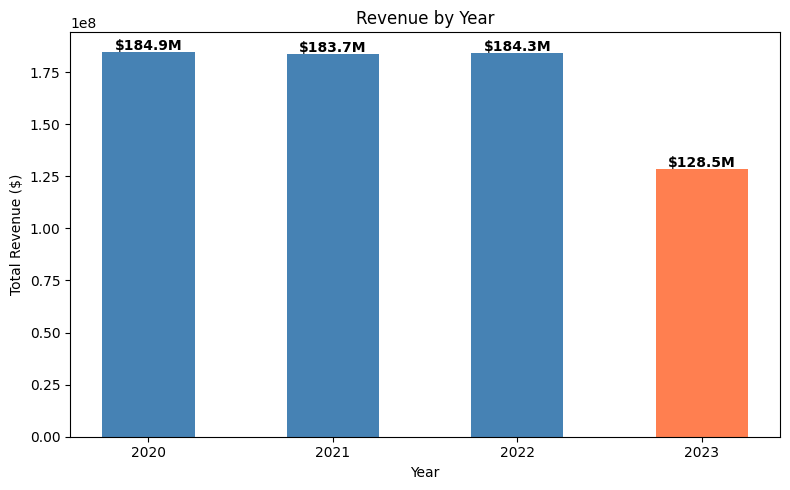

In [12]:
df['Year'] = df['Purchase Date'].dt.year
yearly = df.groupby('Year')['Total Purchase Amount'].sum()
print("Yearly Revenue:")
print(yearly)

# Bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(yearly.index.astype(str), yearly.values, 
               color=['steelblue','steelblue','steelblue','coral'], 
               width=0.5)
for bar, val in zip(bars, yearly.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000000,
             f'${val/1e6:.1f}M', ha='center', fontsize=10, fontweight='bold')
plt.title('Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('yearly_revenue.png')
plt.show()


### Revenue by Year
- 2020: **184.9M**
- 2021: **183.7M**
- 2022: **184.3M**
- 2023: **128.5M**

### Insight
- Revenue remained highly stable between **2020 and 2022**, averaging around **184M** annually.
- **2020 recorded the highest revenue**, closely followed by 2022.
- Revenue in **2023 appears significantly lower**, likely due to incomplete yearly data rather than an actual business decline.
- Overall, the business demonstrates consistent revenue performance across the analyzed years.

Quatrerly Revenue Trend

    Year  Quarter  Total Purchase Amount
0   2020        1               45744832
1   2020        2               45641043
2   2020        3               46899933
3   2020        4               46591696
4   2021        1               45112173
5   2021        2               45657051
6   2021        3               46900393
7   2021        4               46002864
8   2022        1               45174813
9   2022        2               46299953
10  2022        3               46178450
11  2022        4               46691511
12  2023        1               45576239
13  2023        2               45439449
14  2023        3               37435899


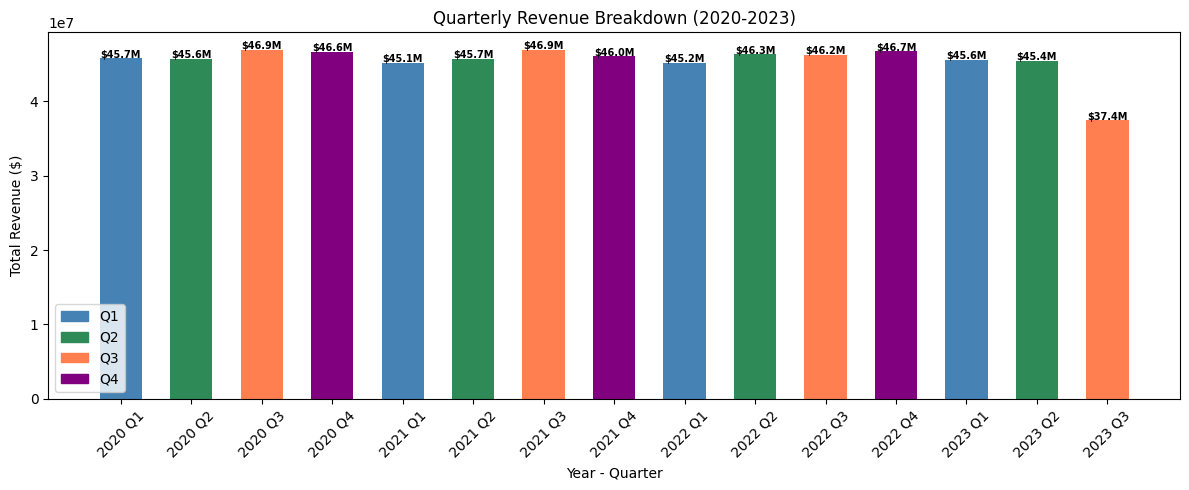

In [13]:
df['Quarter'] = df['Purchase Date'].dt.quarter
quarterly = df.groupby(['Year','Quarter'])['Total Purchase Amount'].sum().reset_index()
print(quarterly)

# Bar chart
plt.figure(figsize=(12,5))
quarterly['Year_Quarter'] = quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)
colors = quarterly['Quarter'].map({1:'steelblue', 2:'seagreen', 3:'coral', 4:'purple'})

bars = plt.bar(quarterly['Year_Quarter'], quarterly['Total Purchase Amount'],
               color=colors, width=0.6)

for bar, val in zip(bars, quarterly['Total Purchase Amount']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100000,
             f'${val/1e6:.1f}M', ha='center', fontsize=7, fontweight='bold')

plt.title('Quarterly Revenue Breakdown (2020-2023)')
plt.xlabel('Year - Quarter')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)

from matplotlib.patches import Patch
legend = [Patch(color='steelblue', label='Q1'),
          Patch(color='seagreen',  label='Q2'),
          Patch(color='coral',     label='Q3'),
          Patch(color='purple',    label='Q4')]
plt.legend(handles=legend)
plt.tight_layout()
plt.savefig('quarterly_revenue.png')
plt.show()

 Payment pie chart

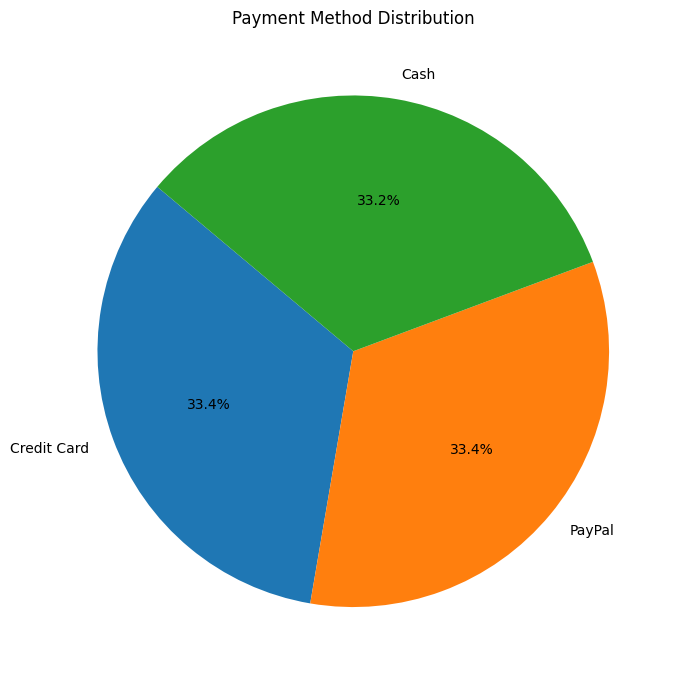

In [14]:

plt.figure(figsize=(7, 7))
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('pie_chart.png')
plt.show()

RETURN ANALYSIS BY PRODUCT

=== RETURN RATE BY CATEGORY ===
Product Category
Books          50.4
Clothing       49.9
Electronics    50.2
Home           49.9
Name: Returns, dtype: float64


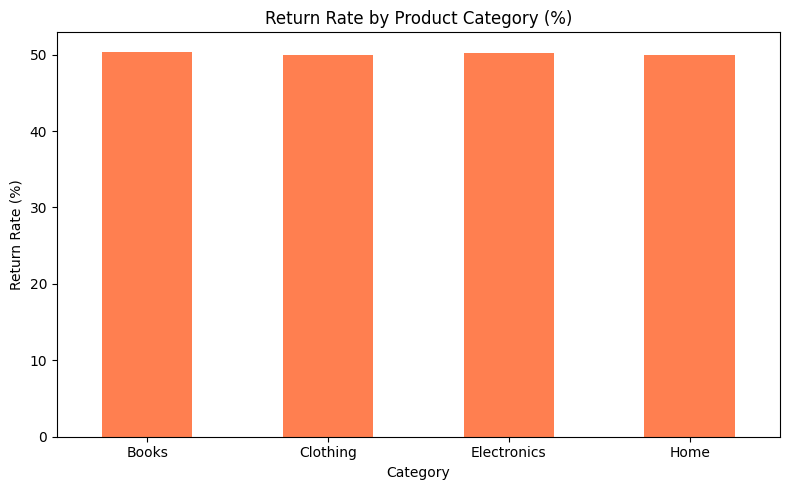

In [15]:

print("=== RETURN RATE BY CATEGORY ===")
return_by_cat = df.groupby('Product Category')['Returns'].mean().round(3) * 100
print(return_by_cat)

plt.figure(figsize=(8, 5))
return_by_cat.plot(kind='bar', color='coral', width=0.5)
plt.title('Return Rate by Product Category (%)')
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('returns_by_category.png')
plt.show()


### Return Percentage
- Books: **50.4%**
- Electronics: **50.2%**
- Clothing: **49.9%**
- Home: **49.9%**
- 
### Insight

Return rates are remarkably consistent across all product categories, ranging from **49.9% to 50.4%**. Books have the highest return rate, while Clothing and Home have the lowest, though the differences are minimal.

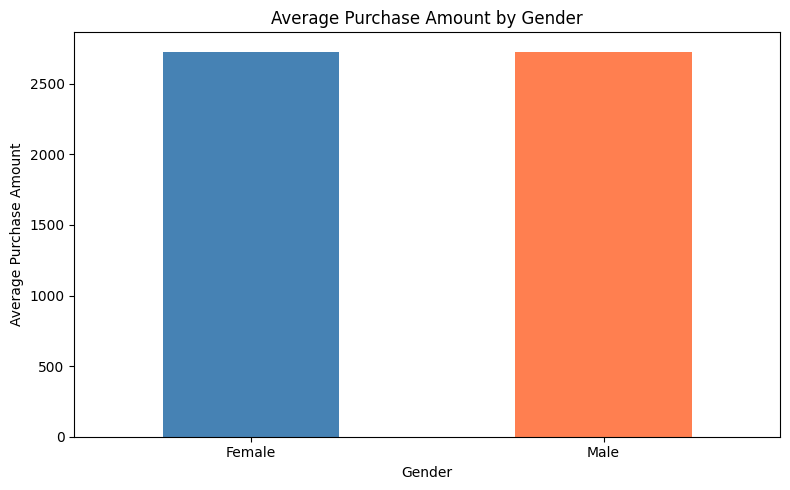

Gender counts: Gender
Male      125676
Female    124324
Name: count, dtype: int64
Gender %: Gender
Male      50.3
Female    49.7
Name: proportion, dtype: float64

Mean Age: 43.8
Median Age: 44.0
Mean Age: 44
Median Age: 44


In [16]:
plt.figure(figsize=(8,5))
df.groupby('Gender')['Total Purchase Amount'].mean().plot(kind='bar', color=['steelblue','coral'])
plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gender_bar.png')
plt.show()


print("Gender counts:", df['Gender'].value_counts())
print("Gender %:", df['Gender'].value_counts(normalize=True).round(3) * 100)
print("\nMean Age:", df['Customer Age'].mean().round(1))
print("Median Age:", df['Customer Age'].median())
print("Mean Age:", int(round(df['Customer Age'].mean())))
print("Median Age:", int(df['Customer Age'].median()))


### Gender Distribution
- Male: **125,676 (50.3%)**
- Female: **124,324 (49.7%)**

### Age Statistics
- Mean Age: **44 years**
- Median Age: **44 years**

### Insight
The customer base is almost evenly split between males and females, indicating balanced gender representation. The average customer age is **44 years**, suggesting that middle-aged adults form the core customer segment.

=== TOTAL REVENUE BY AGE GROUP ===
Age Group
Under 25     88909126
25-34       126650499
35-44       126246353
45-54       128765610
55+         210774711
Name: Total Purchase Amount, dtype: int64

Revenue % by Age Group:
Age Group
Under 25    13.0
25-34       18.6
35-44       18.5
45-54       18.9
55+         30.9
Name: Total Purchase Amount, dtype: float64


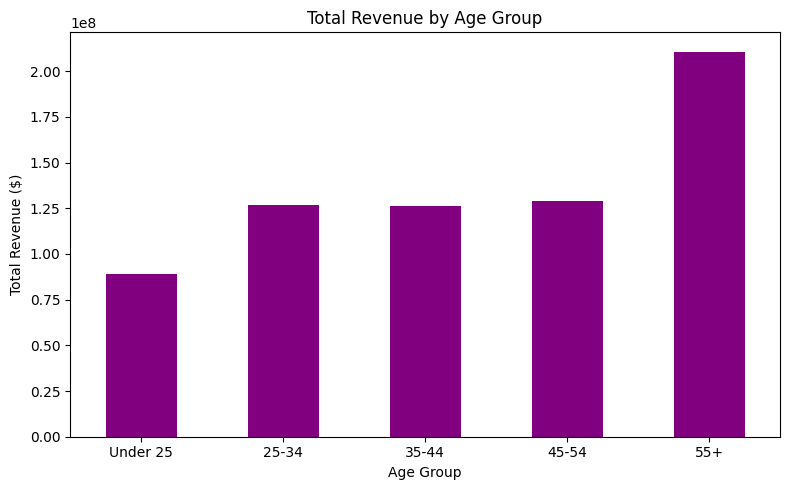

In [18]:

import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the age bins and labels (adjust these ranges to fit your data)
bins = [0, 25, 35, 45, 55, 100]
labels = ['Under 25', '25-34', '35-44', '45-54', '55+']

# 2. Create the 'Age Group' column
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# 3. Now your original code will work perfectly!
print("=== TOTAL REVENUE BY AGE GROUP ===")
age_revenue = df.groupby('Age Group')['Total Purchase Amount'].sum()
age_revenue_pct = (age_revenue / age_revenue.sum() * 100).round(1)

print(age_revenue)
print("\nRevenue % by Age Group:")
print(age_revenue_pct)

plt.figure(figsize=(8, 5))
age_revenue.plot(kind='bar', color='purple', width=0.5)
plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=0) # Added rotation=0 so labels stay horizontal and readable
plt.tight_layout()
plt.show()


### Revenue Distribution

- Under 25: **88.9M (13.0%)**
- 25–34: **126.7M (18.6%)**
- 35–44: **126.2M (18.5%)**
- 45–54: **128.8M (18.9%)**
- 55+: **210.8M (30.9%)**

### Insight

Customers aged **55+ contribute the highest revenue (30.9%)**, making them the most valuable age segment. Customers under 25 generate the lowest share of revenue (13.0%), while the 25–54 age groups contribute relatively similar proportions.

HISTOGRAM (CUSTOMER SPEND DISTRIBUTION)

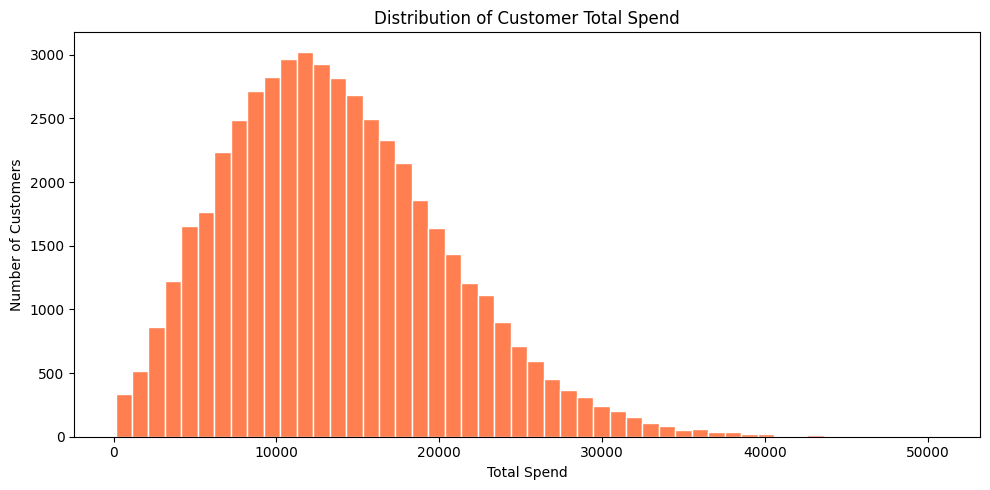

In [19]:
customer_spend = df.groupby('Customer ID')['Total Purchase Amount'].sum()

plt.figure(figsize=(10,5))
plt.hist(customer_spend, bins=50, color='coral', edgecolor='white')
plt.title('Distribution of Customer Total Spend')
plt.xlabel('Total Spend')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('histogram.png')
plt.show()

FEATURE ENGINEERING (RFM)

In [20]:

snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('Purchase Date', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Purchase Date', 'count'),
    Monetary  = ('Total Purchase Amount', 'sum')
).reset_index()

# RFM Scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm['RFM_Total'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

# Segmentation
def segment(score):
    if score >= 12: return 'Champions'
    elif score >= 9: return 'Loyal Customers'
    elif score >= 6: return 'At Risk'
    else: return 'Lost'

rfm['Segment'] = rfm['RFM_Total'].apply(segment)

print("=== RFM Head ===")
print(rfm.head())

print("\n=== RFM Describe ===")
print(rfm.describe())

print("\n=== Segment Counts ===")
print(rfm['Segment'].value_counts())

print("\n=== Avg RFM by Segment ===")
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(0))

=== RFM Head ===
   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0            1      289          3      6290       2       1       1   
1            2       73          6     16481       4       4       4   
2            3      223          4      9423       3       2       2   
3            4      442          5      7826       1       3       2   
4            5      425          5      9769       2       3       2   

   RFM_Total    Segment  
0          4       Lost  
1         12  Champions  
2          7    At Risk  
3          6    At Risk  
4          7    At Risk  

=== RFM Describe ===
        Customer ID       Recency     Frequency      Monetary     RFM_Total
count  49661.000000  49661.000000  49661.000000  49661.000000  49661.000000
mean   24993.104488    262.335374      5.034131  13719.947222      9.002517
std    14434.429306    246.804539      2.199399   6811.065854      3.453630
min        1.000000      1.000000      1.000000    125.000000      3

#CUSTOMER SEGMENT DISTRIBUTION

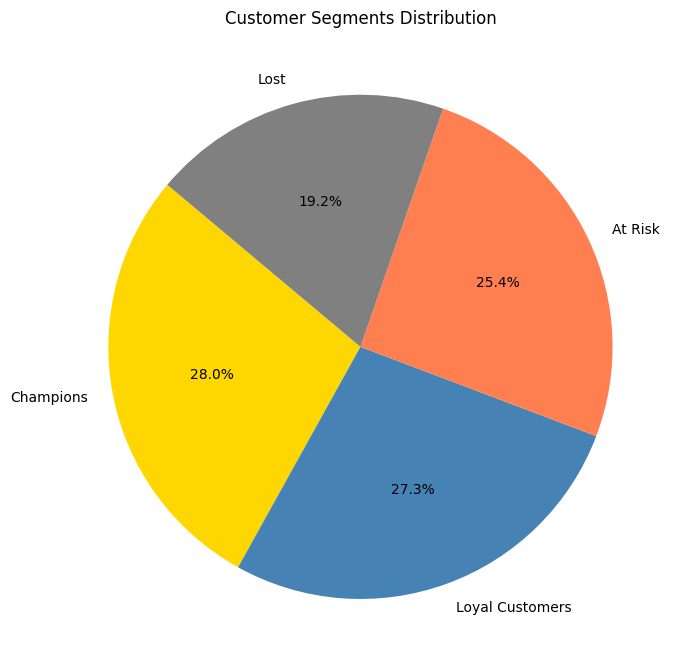

In [21]:

plt.figure(figsize=(7,7))
rfm['Segment'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', 
    colors=['gold','steelblue','coral','gray'],
    startangle=140)
plt.title('Customer Segments Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('segments_pie.png')
plt.show()

In [22]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Total'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0            1      289          3      6290       2       1       1   
1            2       73          6     16481       4       4       4   
2            3      223          4      9423       3       2       2   
3            4      442          5      7826       1       3       2   
4            5      425          5      9769       2       3       2   

   RFM_Total    Segment  
0          4       Lost  
1         12  Champions  
2          7    At Risk  
3          6    At Risk  
4          7    At Risk  


## RFM Segmentation Sample

RFM analysis categorizes customers based on their purchasing behavior.

### Insight
- High RFM scores indicate **Champions**.
- Low RFM scores indicate **Lost** customers.
- Mid-range scores identify customers **At Risk** of churn.

CUSTOMER SEGMENTATION

In [23]:
def segment(score):
    if score >= 12: return 'Champions'
    elif score >= 9: return 'Loyal Customers'
    elif score >= 6: return 'At Risk'
    else: return 'Lost'

rfm['Segment'] = rfm['RFM_Total'].apply(segment)
print(rfm['Segment'].value_counts())

Segment
Champions          13928
Loyal Customers    13559
At Risk            12637
Lost                9537
Name: count, dtype: int64


## Customer Segmentation

- Champions: **13,928**
- Loyal Customers: **13,559**
- At Risk: **12,637**
- Lost Customers: **9,537**

### Insight
The largest customer groups are **Champions** and **Loyal Customers**, indicating a strong base of high-value customers. However, a significant number of customers are **At Risk** or **Lost**, highlighting the need for targeted retention strategies.

## RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is used to evaluate customer value and purchasing behavior.

- Recency: How recently a customer purchased.
- Frequency: How often a customer purchases.
- Monetary: How much a customer spends.

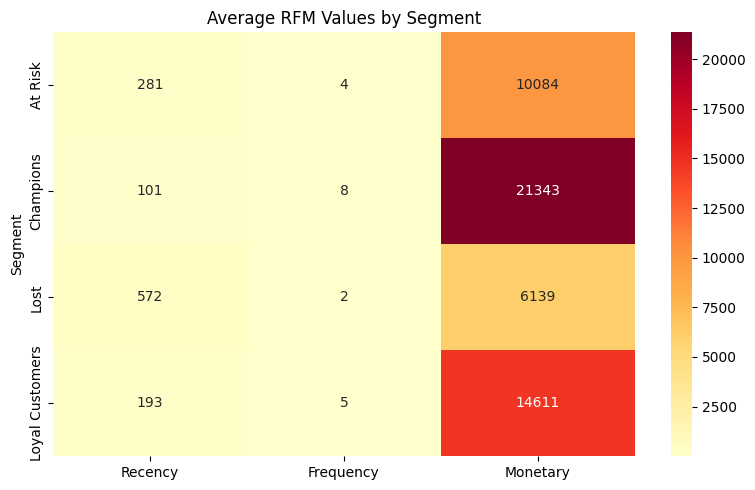

In [24]:
seg_profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

plt.figure(figsize=(8,5))
sns.heatmap(seg_profile, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Average RFM Values by Segment')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

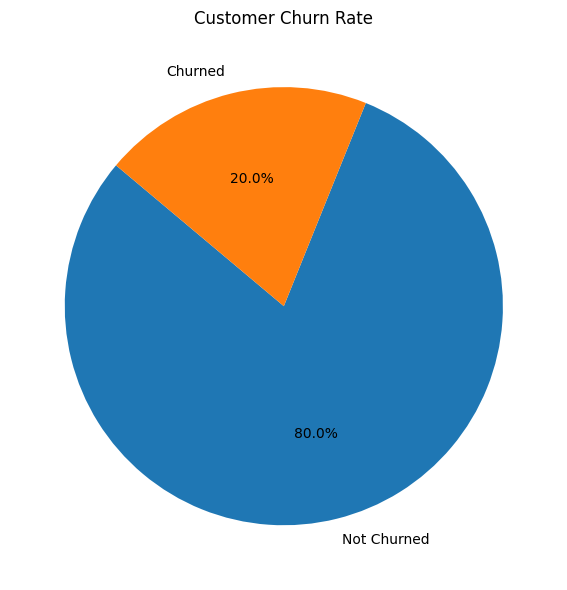

Churned: Churn
0    39732
1     9929
Name: count, dtype: int64
Churn %: Churn
0    80.0
1    20.0
Name: proportion, dtype: float64


In [25]:
churn = df.groupby('Customer ID')['Churn'].max().reset_index()
churn_rate = churn['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
churn_rate.plot(kind='pie', autopct='%1.1f%%', labels=['Not Churned','Churned'], startangle=140)
plt.title('Customer Churn Rate')
plt.ylabel('')
plt.tight_layout()
plt.savefig('churn_pie.png')
plt.show()
churn = df.groupby('Customer ID')['Churn'].max().reset_index()
print("Churned:", churn['Churn'].value_counts())
print("Churn %:", churn['Churn'].value_counts(normalize=True).round(3) * 100)


## Customer Churn Distribution

- Active Customers: **39,732 (80%)**
- Churned Customers: **9,929 (20%)**

### Insight
Most customers remain active, while **20% have churned**, indicating an opportunity to improve customer retention.

PURCHASE PATTERN BY GENDER

In [26]:
print("Unique Customers:", df['Customer ID'].nunique())

Unique Customers: 49661


#SUMMARY REPORT

In [27]:
# FINAL SUMMARY
print("=" * 50)
print("CUSTOMER BEHAVIOR ANALYSIS — SUMMARY")
print("=" * 50)
print(f"Total Transactions       : {len(df):,}")
print(f"Unique Customers         : {df['Customer ID'].nunique():,}")
print(f"Date Range               : {df['Purchase Date'].min().date()} to {df['Purchase Date'].max().date()}")
print(f"Total Revenue            : ${df['Total Purchase Amount'].sum():,.0f}")
print(f"Avg Purchase Amount      : ${df['Total Purchase Amount'].mean():,.2f}")
print(f"Avg Customer Age         : {df['Customer Age'].mean():.1f} years")
print("-" * 50)
print(f"Top Product Category     : {df['Product Category'].mode()[0]}")
print(f"Top Payment Method       : {df['Payment Method'].mode()[0]}")
print(f"Male %                   : {(df['Gender']=='Male').mean()*100:.1f}%")
print(f"Female %                 : {(df['Gender']=='Female').mean()*100:.1f}%")
print("-" * 50)
print(f"Churn Rate               : {churn['Churn'].mean()*100:.1f}%")
print(f"Retained Customers       : {(churn['Churn']==0).sum():,}")
print(f"Churned Customers        : {(churn['Churn']==1).sum():,}")
print("-" * 50)
print(f"Champions                : {(rfm['Segment']=='Champions').sum():,} ({(rfm['Segment']=='Champions').mean()*100:.1f}%)")
print(f"Loyal Customers          : {(rfm['Segment']=='Loyal Customers').sum():,} ({(rfm['Segment']=='Loyal Customers').mean()*100:.1f}%)")
print(f"At Risk                  : {(rfm['Segment']=='At Risk').sum():,} ({(rfm['Segment']=='At Risk').mean()*100:.1f}%)")
print(f"Lost                     : {(rfm['Segment']=='Lost').sum():,} ({(rfm['Segment']=='Lost').mean()*100:.1f}%)")
print(f"Overall Return Rate      : {df['Returns'].mean()*100:.1f}%")
print("=" * 50)

CUSTOMER BEHAVIOR ANALYSIS — SUMMARY
Total Transactions       : 250,000
Unique Customers         : 49,661
Date Range               : 2020-01-01 to 2023-09-13
Total Revenue            : $681,346,299
Avg Purchase Amount      : $2,725.39
Avg Customer Age         : 43.8 years
--------------------------------------------------
Top Product Category     : Electronics
Top Payment Method       : Credit Card
Male %                   : 50.3%
Female %                 : 49.7%
--------------------------------------------------
Churn Rate               : 20.0%
Retained Customers       : 39,732
Churned Customers        : 9,929
--------------------------------------------------
Champions                : 13,928 (28.0%)
Loyal Customers          : 13,559 (27.3%)
At Risk                  : 12,637 (25.4%)
Lost                     : 9,537 (19.2%)
Overall Return Rate      : 50.1%


### Overview

This project analyzes 250,000 e-commerce transactions from 49,661 unique customers spanning January 2020 to September 2023. The goal was to understand customer purchasing behavior, segment customers using RFM modeling, identify churn risk, and uncover revenue patterns across categories, payment methods, and demographics. Dataset

Source: Kaggle — Customer Behavior Analysis Records: 250,000 transactions Period: January 2020 – September 2023 Features: Customer ID, Purchase Date, Product Category, Product Price, Quantity, Total Purchase Amount, Payment Method, Customer Age, Returns, Gender, Churn

### Analysis Performed

Summary statistics — mean, median, mode across key metrics Total sales and revenue breakdown by product category Yearly, quarterly, and monthly revenue trends Payment method distribution RFM segmentation — Champions, Loyal, At Risk, Lost Customer churn analysis Returns analysis by category and gender Purchase patterns by gender and age group

### Key Findings

Total revenue of ~$681M stable at ~$184M annually from 2020–2022 Champions (28%) and Loyal Customers (27.3%) form 55.3% of the base 20% churn rate — 1 in 5 customers lost Credit Card is the top payment method at 33.4% ~50% return rate uniformly across all categories and genders 55+ age group drives the highest revenue at ~$198M (29.1%)

### Tools & Libraries
Python 3 | Environment: Jupyter Notebook Libraries: Pandas, NumPy, Matplotlib, Seaborn

### NOTE:THE BRIEF OF THE ANALYSIS IS SHARED WITHIN THE PDF FILE

END OF REPORT| ADITI KUMARI | ALFIDO TECH INTERNSHIP | 
